# Things to do
- Replace node with its children after the split (DTree becomes the a list that holds the grid)
- Sort the rectangles according to their score
- after split search (use binary search) to place the new rectangles where they belong. This may be useful, but I am not sure 
- only compute score at the split
- allow uneven split. Each axis can be split in other ways than 50-50.

In [1]:
import numpy as np

#-------------------------#
import ipympl

%matplotlib ipympl
# %matplotlib widget
#-------------------------#
import matplotlib.pyplot as plt
import mpl_interactions.ipyplot as iplt
#-------------------------#

from matplotlib.patches import Rectangle as plt_rec


In [2]:
def show_rec(rec,**kwargs):
    return plt_rec(
        (rec.center[0]-rec.distances[0],rec.center[1]-rec.distances[1]),   
        rec.distances[0]*2, #height
        rec.distances[1]*2, #width
        **kwargs)

In [3]:
class Rectangle:
    def __init__(self,center,distances):
        '''
        center: the geometric center (d-dimensional array).
        distances: distance of the center of each axis to the edge of the axis (d-dimensional array).

        If I have the 2d rectange with vertices at {(0,0), (0,2), (1,0), (1,2)}
        the center is (0.5, 1). Alternative way of thinking about it: the two sides parallel to the x-axis have a 
        center at x = 0.5 and the two sides parallel to the y-axis have a center at y = 1. The corresponding
        distances are 0.5 and 1.
        '''
        
        self.center=center[:]
        self.distances=distances[:]
        self.dim=len(center)

        self.vertex_points()
        
    def sign(self,i,j):
        r'''
            This generates an alternating pattern of signs that enumerates all 2^d
            possible sign vectors of a d-dimensional rectangle.
            
            Each sign vector tells us how to move from the center of the rectangle to one
            vertex:
            
                vertex = center + sign_vector * distances_d
            
            The same sign vectors can also be used to locate the centers of the
            subrectangles after subdivision:
            
                child_center = center + sign_vector * (distances_d / 2)
            

            My way of thinking:
            If you imagine a circle divided into j equal picies with \delta\theta=\pi/(2^(j-1)), 
            then the sign can be defined as + if \theta = i*\delta\theta <= \pi and - if \theta = i*\delta\theta > \pi.
            
            Alternative way of thinking:
            For each coordinate j, the sign is a 'square wave' as a function of the
            vertex (or child) index i. The last coordinate flips every step, the previous
            one flips every two steps, the previous one every four steps, and so on.
            Equivalently, coordinate j flips every 2^(d-j-1) steps.

            This is the idea this fucntion follows.
        '''
        #shift to call i,j as a list that start from 0 at 0
        i=i+1
        j=j+1
        
        dt=1/2**(j-1)#the step in units of \pi
        t=(i-1)#the steps you take, i=\theta/\delta\theta

        semicircle=np.floor((t*dt)%2)#this checks whether you are in the upper or lower half of the circle
        return int((-1)**semicircle)#this gives you the sign
    

    def volume(self):
        '''Return the volume of this rectangle.'''
        v=1
        for dis in self.distances:
            v*=2*dis
        return v

    def vertex_points(self):
        '''generate all vertex points of the rectangle'''
        
        self.vertices=[]
        for bound in range(2**self.dim):
            self.vertices.append([self.center[d]+self.distances[d]*self.sign(bound,d) for d in range(self.dim)])

    
    def check_point(self,point):
        '''check whether point is inside this rectangle'''
        for d in range(self.dim):
            if point[d]>self.center[d]+self.distances[d] or point[d]<self.center[d]-self.distances[d]:
                return False
        return True

    def random_point(self):
        '''generate a random point in this rectangle'''
        
        point=[]
        for d in range(self.dim):
            _M=self.center[d]+self.distances[d]
            _m=self.center[d]-self.distances[d]
            point.append(np.random.rand()*(_M-_m)+_m)
            
        return point

In [4]:
r=Rectangle(center=[0.1,0.2],distances=[0.5,0.7])
c=Rectangle(center=[0.5,0.5],distances=[0.3,0.3])


In [5]:
if False:
    points_r=np.array([r.random_point() for _ in range(50)])
    points_c=np.array([c.random_point() for _ in range(50)])

    overlap=[]
    for _ in np.concatenate([points_c,points_r]):
        if r.check_point(_) and c.check_point(_):
            overlap.append(_)
    overlap=np.array(overlap)
    fig=plt.figure(figsize=(4,4))
    fig.subplots_adjust(bottom=0.1, left=0.1, top = 0.9, right=0.9,wspace=0.0,hspace=0.5)
    
    sub = fig.add_subplot(111)
    
    
    sub.add_patch(show_rec(c,fill=False,color='xkcd:blue'))
    sub.add_patch(show_rec(r,fill=False,color='xkcd:red'))
    
    
    sub.scatter(points_r[:,0],points_r[:,1],s=1,color='xkcd:red')
    sub.scatter(points_c[:,0],points_c[:,1],s=1,color='xkcd:blue')
    
    sub.scatter(overlap[:,0],overlap[:,1],s=25,color='xkcd:black',facecolor='None')
    
    sub.set_xlim(-1,1)
    sub.set_ylim(-1,1)
    plt.show()

In [6]:
class DTree:
    '''
    The DTree class recursively splits the chosen axes.
    '''
    def __init__(self,boundary,max_splits=np.inf,score=0,splits=0,parent=None):
        '''
        boundary: an instance of Rectangle. It is the rectangle that defines this "node" of the tree.
        
        max_splits: number of allowed splits
        
        score: This is a number. I will use this to assign values to each rectangle and later decide to split an axis it or not. 
        
        splits: number of splits of current node

        parent: the parent node
        '''
        
        #We deal with rectangles, but use the dim when you can. It will be easier to generalize later.
        self.dim=boundary.dim
            
        self.boundary=boundary
        self.score=score
        self.scored=False
        self.max_splits=max_splits
        self.splits=splits
        
        #List of intances of DTree. This will hold the potential rectangles.
        #Each instance of DTree has either 0 or 2 children. The reason is that
        # split one axis at a time to keep the memory in check
        self.children=[0,0]
        self.has_children=False
        
        self.max_reached = self.splits >= self.max_splits
        self.parent=parent


    def split(self,axis):
        '''
        split the current rectangle along the "axis" axis
        axis: the axis to split
        '''            
        if self.splits >= self.max_splits:
            return

        self.has_children=True
        
        new_distances = self.boundary.distances[:]
        new_distances[axis] = self.boundary.distances[axis] / 2.
    
        for j, sign in enumerate([-1, +1]):
            new_center = self.boundary.center[:]
            new_center[axis] = self.boundary.center[axis] + sign * new_distances[axis]            
            self.children[j]=DTree( boundary=Rectangle(new_center,new_distances), 
                                max_splits=self.max_splits, score=0, splits=self.splits+1,
                                parent = self )

        if self.children[0].max_reached:#both children have same splits. 
            self.assign_max_reached()
        
    def assign_score(self, score_function):
        '''
        Run score_function in each rectangle to assign the scores. Note that I want to 
        assign a value at the last nodes because these are the ones that I may split.
        
        score_function: a function that takes a node (not just a rectangle) and returns a number.
        '''
        if self.max_reached:
            return
        if self.has_children:
            for node in self.children:
                node.assign_score(score_function)
        else:
            if not self.scored:
                self.score=score_function(self)
                self.scored=True


    def conditional_split(self, score_function, condition):
        '''
        check the score and split if condition returns True.
        
        condition: a function that takes a value and returns True or False.
        '''
        if self.max_reached:
            return

        if self.has_children:
            for node in self.children:
                node.conditional_split(score_function,condition)
        else:
            if condition(self.score):
                #split a random axis
                # axis=np.random.choice(range(self.dim))
                # split by maximizing the score difference
                axis=self.axis_to_split(score_function)
                self.split(axis)


    def test_split(self,axis):
        '''
        split the current rectangle along the "axis" axis
        instead of making them children, you just return
        the would-be children
        '''            
        new_distances = self.boundary.distances[:]
        new_distances[axis] = self.boundary.distances[axis] / 2.
        children=[0,0]
        for j, sign in enumerate([-1, +1]):
            new_center = self.boundary.center[:]
            new_center[axis] = self.boundary.center[axis] + sign * new_distances[axis]            
            children[j]=DTree( boundary=Rectangle(new_center,new_distances), 
                                max_splits=self.max_splits, score=0, splits=self.splits+1)
        return children
        

    
    def axis_to_split(self, score_function):
        '''
        Split all axes, compute score, and return the
        axis that splits the score as unevenly as possible.
        '''
        best_axis = 0
        
        nodes = self.test_split(best_axis)
        score_0 = score_function(nodes[0])
        score_1 = score_function(nodes[1])
        best_imbalance = abs(score_0 - score_1)
    
        for axis in range(1, self.dim):
            nodes = self.test_split(axis)
    
            score_0 = score_function(nodes[0])
            score_1 = score_function(nodes[1])
    
            imbalance = abs(score_0 - score_1)
    
            if imbalance > best_imbalance:
                best_imbalance = imbalance
                best_axis = axis
    
        return best_axis

        
    
    def assign_max_reached(self):
        '''
        An end node has max_reached=True if its splits is >= max_splits.
    
        An internal node has max_reached=True if **all of its children** have
        max_reached=True. The reason is that I don't want to stop subdivision
        of a node if another node has already reached its maximum splits. 
    
        After updating this node, propagate the update to the parent.
        '''
        if self.has_children:
            self.max_reached = True
            for node in self.children:
                if not node.max_reached:
                    self.max_reached = False
        else:
            self.max_reached = self.splits >= self.max_splits
    
        if self.parent is not None:
            self.parent.assign_max_reached()        
 
    
    def get_all_rectangles(self):
        '''Get all the rectangles of the tree and its children recursively'''
        rectangles = [(self.splits,self.boundary)]
    
        if self.has_children:
            for i in self.children:
                for c in i.get_all_rectangles():
                    rectangles.append(c)
        return rectangles


    def get_rectangles(self,rectangles = None):
        '''Get the end rectangles of the tree'''
        if rectangles is None:
            rectangles=[]
    
        if self.has_children:
            for node in self.children:
                node.get_rectangles(rectangles)
        else:
            rectangles.append((self.splits,self.boundary))
        return rectangles                

    
    def get_end_nodes(self, nodes=None):
        '''
        Return the end nodes of the tree.
        '''
        if nodes is None:
            nodes = []
    
        if self.has_children:
            for node in self.children:
                node.get_end_nodes(nodes)
        else:
            nodes.append(self)
    
        return nodes
    
    def get_scores(self,scores = None):
        '''
        return a list of scores of the end node
        '''
        if scores is None:
            scores=[]
        
        if self.has_children:
            for node in self.children:
                node.get_scores(scores)
        else:
            scores.append(self.score)
        return scores


    def random_points(self,number_of_points):
        '''
        Generate random points inside the rectangles. 
        I want to choose a random rectangle according to
        the distribution  p_i ~ 1/node[i].boundary.volume().   
        
        To do this, I choose a random node, and sample inside it.
        '''
        nodes=self.get_end_nodes()
        points=[]
        while len(points)<number_of_points:
            
            i=np.random.choice( len(nodes) )
            
            points.append(nodes[i].boundary.random_point())
        return points


    def random_points_mass_weighted(self, number_of_points):
        '''
        Generate random points by choosing each rectangle with probability
        proportional to its mass.
    
        Assumes node.score is the mass of the rectangle:
            score_i = integral over rectangle i.
        '''
        nodes = self.get_end_nodes()
    
        masses = np.array([node.score for node in nodes], dtype=float)
        masses = np.maximum(masses, 0)
    
        probabilities = masses / np.sum(masses)
    
        points = []
        while len(points) < number_of_points:
            i = np.random.choice(len(nodes), p=probabilities)
            points.append(nodes[i].boundary.random_point())
    
        return points

In [7]:
#generate a number of points from a gaussian
# points = np.random.normal([0.5,0],[0.1,0.1],(1500,2))
# points = np.random.uniform(0,0.3,(500,2))


theta = np.pi / 3   
u = np.array([np.cos(theta), np.sin(theta)])
v = np.array([-np.sin(theta), np.cos(theta)])
sigma_parallel = 0.01
sigma_perp = 0.1
cov = sigma_parallel**2 * np.outer(u, u) + sigma_perp**2 * np.outer(v, v)
p1=np.random.multivariate_normal([0.3, 0], cov, size=1500)

theta = np.pi / 10  
u = np.array([np.cos(theta), np.sin(theta)])
v = np.array([-np.sin(theta), np.cos(theta)])
sigma_parallel = 0.5
sigma_perp = 0.005
cov = sigma_parallel**2 * np.outer(u, u) + sigma_perp**2 * np.outer(v, v)
p2=np.random.multivariate_normal([0.6, -0.5], cov, size=1500)

points = np.concatenate(
    [   
        p1,p2,
        np.random.normal([-0.4,0.5],[0.1,0.1],(1500,2))
    ]
    
    )


In [8]:
#at a node, check the number of points
def number_of_points(node):
    score=0
    for point in points:
        #avoid branches by adding 1 or 0 depending on true or false
        score+=float(node.boundary.check_point(point))        
    return score

In [9]:
tree=DTree(Rectangle([0,0],[1,1]),50)
for _ in range(250):
    
    tree.assign_score( score_function = number_of_points )
    
    tree.conditional_split(score_function = number_of_points, condition= lambda score: score>10)

In [10]:
rectangles=tree.get_rectangles()
# 
# rectangle_points=np.array(tree.random_points(5000))
# rectangle_points_mass=np.array(tree.random_points_mass_weighted(5000))

(-1.5, 1.5)

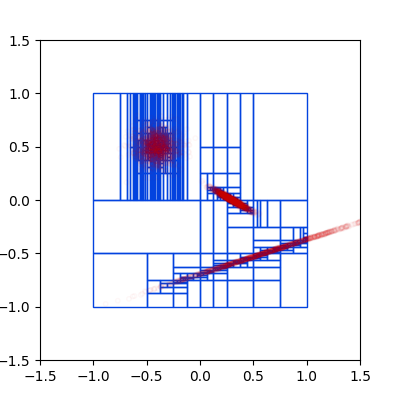

In [11]:
fig=plt.figure(figsize=(4,4))
fig.subplots_adjust(bottom=0.1, left=0.1, top = 0.9, right=0.9,wspace=0.0,hspace=0.5)

sub = fig.add_subplot(111)

for splits,c in rectangles:
    sub.add_patch(show_rec(c,fill=False,color='xkcd:blue'))

sub.scatter(points[:,0],points[:,1],s=10,edgecolor='xkcd:red',facecolors="none",alpha=0.03)
# sub.scatter(rectangle_points[:,0],rectangle_points[:,1],s=1,edgecolor='xkcd:black',facecolors="none",alpha=0.03)
# sub.scatter(rectangle_points_mass[:,0],rectangle_points_mass[:,1],s=5,edgecolor='xkcd:blue',facecolors="none",alpha=0.01)



sub.set_xlim(-1.5,1.5)
sub.set_ylim(-1.5,1.5)
# plt.show()

In [13]:
max([i.splits for i in tree.get_end_nodes()])

18

In [14]:
len(tree.get_end_nodes())

792